In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('flight_pricing_dataset.csv')
df_clean = df.copy()
df_clean = df_clean.drop_duplicates()
print(df_clean.dtypes)
#all the datatypes are string


Flight_ID                str
Airline                  str
Source                   str
Destination              str
Departure_Date           str
Departure_Time           str
Arrival_Time             str
Duration                 str
Total_Stops              str
Distance_km              str
Travel_Class             str
Days_Before_Departure    str
Season                   str
Weekday                  str
Aircraft_Type            str
Booking_Channel          str
Passenger_Count          str
Price                    str
dtype: object


In [ ]:
# many values of distance have km attached to it. we have to clean it.
#Clean 'Distance_km' (remove ' km' text and convert to numeric)
df_clean['Distance_km'] = df_clean['Distance_km'].astype(str).str.replace(' km', '', regex = False)
df_clean['Distance_km'] = pd.to_numeric(df_clean['Distance_km'], errors='coerce')


In [ ]:
#some values of price has Rs. attached to it. we have to strip that and convert it to numeric 
df_clean['Price'] = df_clean['Price'].astype(str).str.replace('Rs. ','',regex = False)
df_clean['Price'] = pd.to_numeric(df_clean['Price'],errors='coerce')

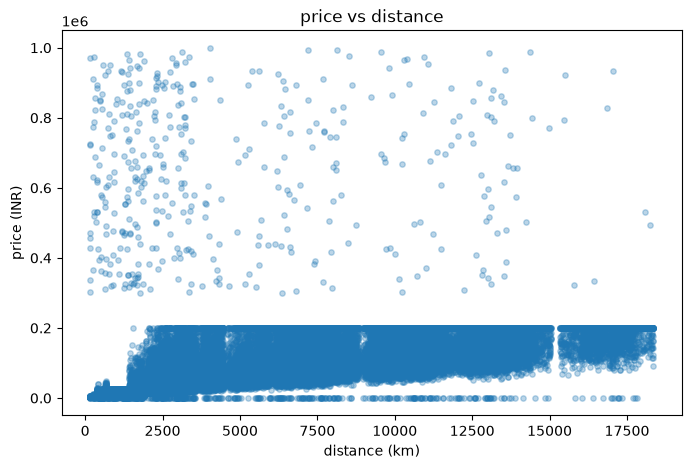

In [ ]:
plt.figure(figsize=(8,5))
distprice = df_clean.dropna(subset=['Distance_km','Price'])
plt.scatter(distprice['Distance_km'],distprice['Price'],alpha=0.3,s=15)
plt.title('price vs distance')
plt.xlabel('distance (km)')
plt.ylabel('price (INR)')
plt.show()
 

1) massive price branding from 0 to 2 lakh
2) the dots higher up could be representing extreme luxury flights, private charters or corrupted/error records
3) price starts from 0 and has an upward slope until around 2000km. after that price ceiling is constant at 2 lakh regardless of extra distance

In [ ]:
df_clean['Airline'] = df_clean['Airline'].astype(str).str.upper()
airlineprice = df_clean.dropna(subset=['Airline','Price']).groupby('Airline')['Price'].mean()
print(airlineprice.head()) 

TypeError: dtype 'str' does not support operation 'mean'